## Plotting Centrolign SV size distribution alongside expected STV sizes 

In [1]:
# Import statements
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

In [2]:
## read in saved dataframe containing all SV calls along with pairwise distance 
df_sv_sorted = pd.read_parquet("/private/groups/patenlab/mira/centrolign/analysis/SVs_pairwise/all_chroms_SV_df.parquet")

In [3]:
### Add new column to dataframe classifying the "shape" category of each SV 
def classify_shape(diff):
    if diff == -1:
        return "triangle"
    elif 0 <= diff <= 0.1:
        return "parallelogram"
    elif diff > 0.1:
        return "trapezoid"
    else:
        return np.nan

In [5]:
df_sv_sorted["shape"] = df_sv_sorted["diff"].apply(classify_shape)

df_sv_sorted.head()

,sample1,start1,end1,sample2,start2,end2,type,diff,clade,chr,source_file,length,pairwise_dist,shape
0,HG002.1,963,11456,HG03742.2,963,964,D,-1.0,chr5_subgroup0,chr5,HG002.1_HG03742.2.bed,10493,0.917844,triangle
1,HG002.1,13009,16731,HG03742.2,2516,2517,D,-1.0,chr5_subgroup0,chr5,HG002.1_HG03742.2.bed,3722,0.917844,triangle
2,HG002.1,16882,16883,HG03742.2,2667,3006,I,-1.0,chr5_subgroup0,chr5,HG002.1_HG03742.2.bed,339,0.917844,triangle
3,HG002.1,16924,17264,HG03742.2,3048,3049,D,-1.0,chr5_subgroup0,chr5,HG002.1_HG03742.2.bed,340,0.917844,triangle
4,HG002.1,20842,23243,HG03742.2,6626,6627,D,0.0,chr5_subgroup0,chr5,HG002.1_HG03742.2.bed,2401,0.917844,parallelogram


In [6]:
### read in SV length distributions with expected HOR sizes from the annotations 

# read in CHM13 HOR sizes > 5% 
chm13_stvs = pd.read_csv("/private/groups/patenlab/mira/centrolign/annotations/stvs_gt.05_12092025_chrfix.tsv", sep="\t")

chm13_stvs.head()

,chr,name,min_range,max_range,counts,chrom_freq
0,chr1,S1C1/5/19H1L.1-5(_6/4_5){1}-6,1230,1388,79669.0,0.072574
1,chr1,S1C1/5/19H1L.1-5(_6/4_5){2}-6,1567,1870,111865.0,0.101903
2,chr1,S1C1/5/19H1L.1-5(_6/4_5){3}-6,1939,2211,102308.0,0.093197
3,chr1,S1C1/5/19H1L.1-5(_6/4_5){4}-6,2282,2550,70546.0,0.064264
4,chr1,S1C1/5/19H1L.1-5(_6/4_5){5}-6,2618,2893,65519.0,0.059685


#### Plot STV sizes for triangles and trapezoids where dist < 0.4

In [7]:
df_sub = df_sv_sorted[
    (df_sv_sorted['shape'].isin(['triangle', 'trapezoid'])) &
    (df_sv_sorted['pairwise_dist'] < 0.4)
]

In [10]:
# Sort chromosomes naturally
def chr_sort_key(c):
    try:
        return int(c.replace("chr", ""))
    except:
        return 9999
        
chromosomes = sorted(df_sub["chr"].unique(), key=chr_sort_key)

/data/tmp/ipykernel_1397777/1035941518.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


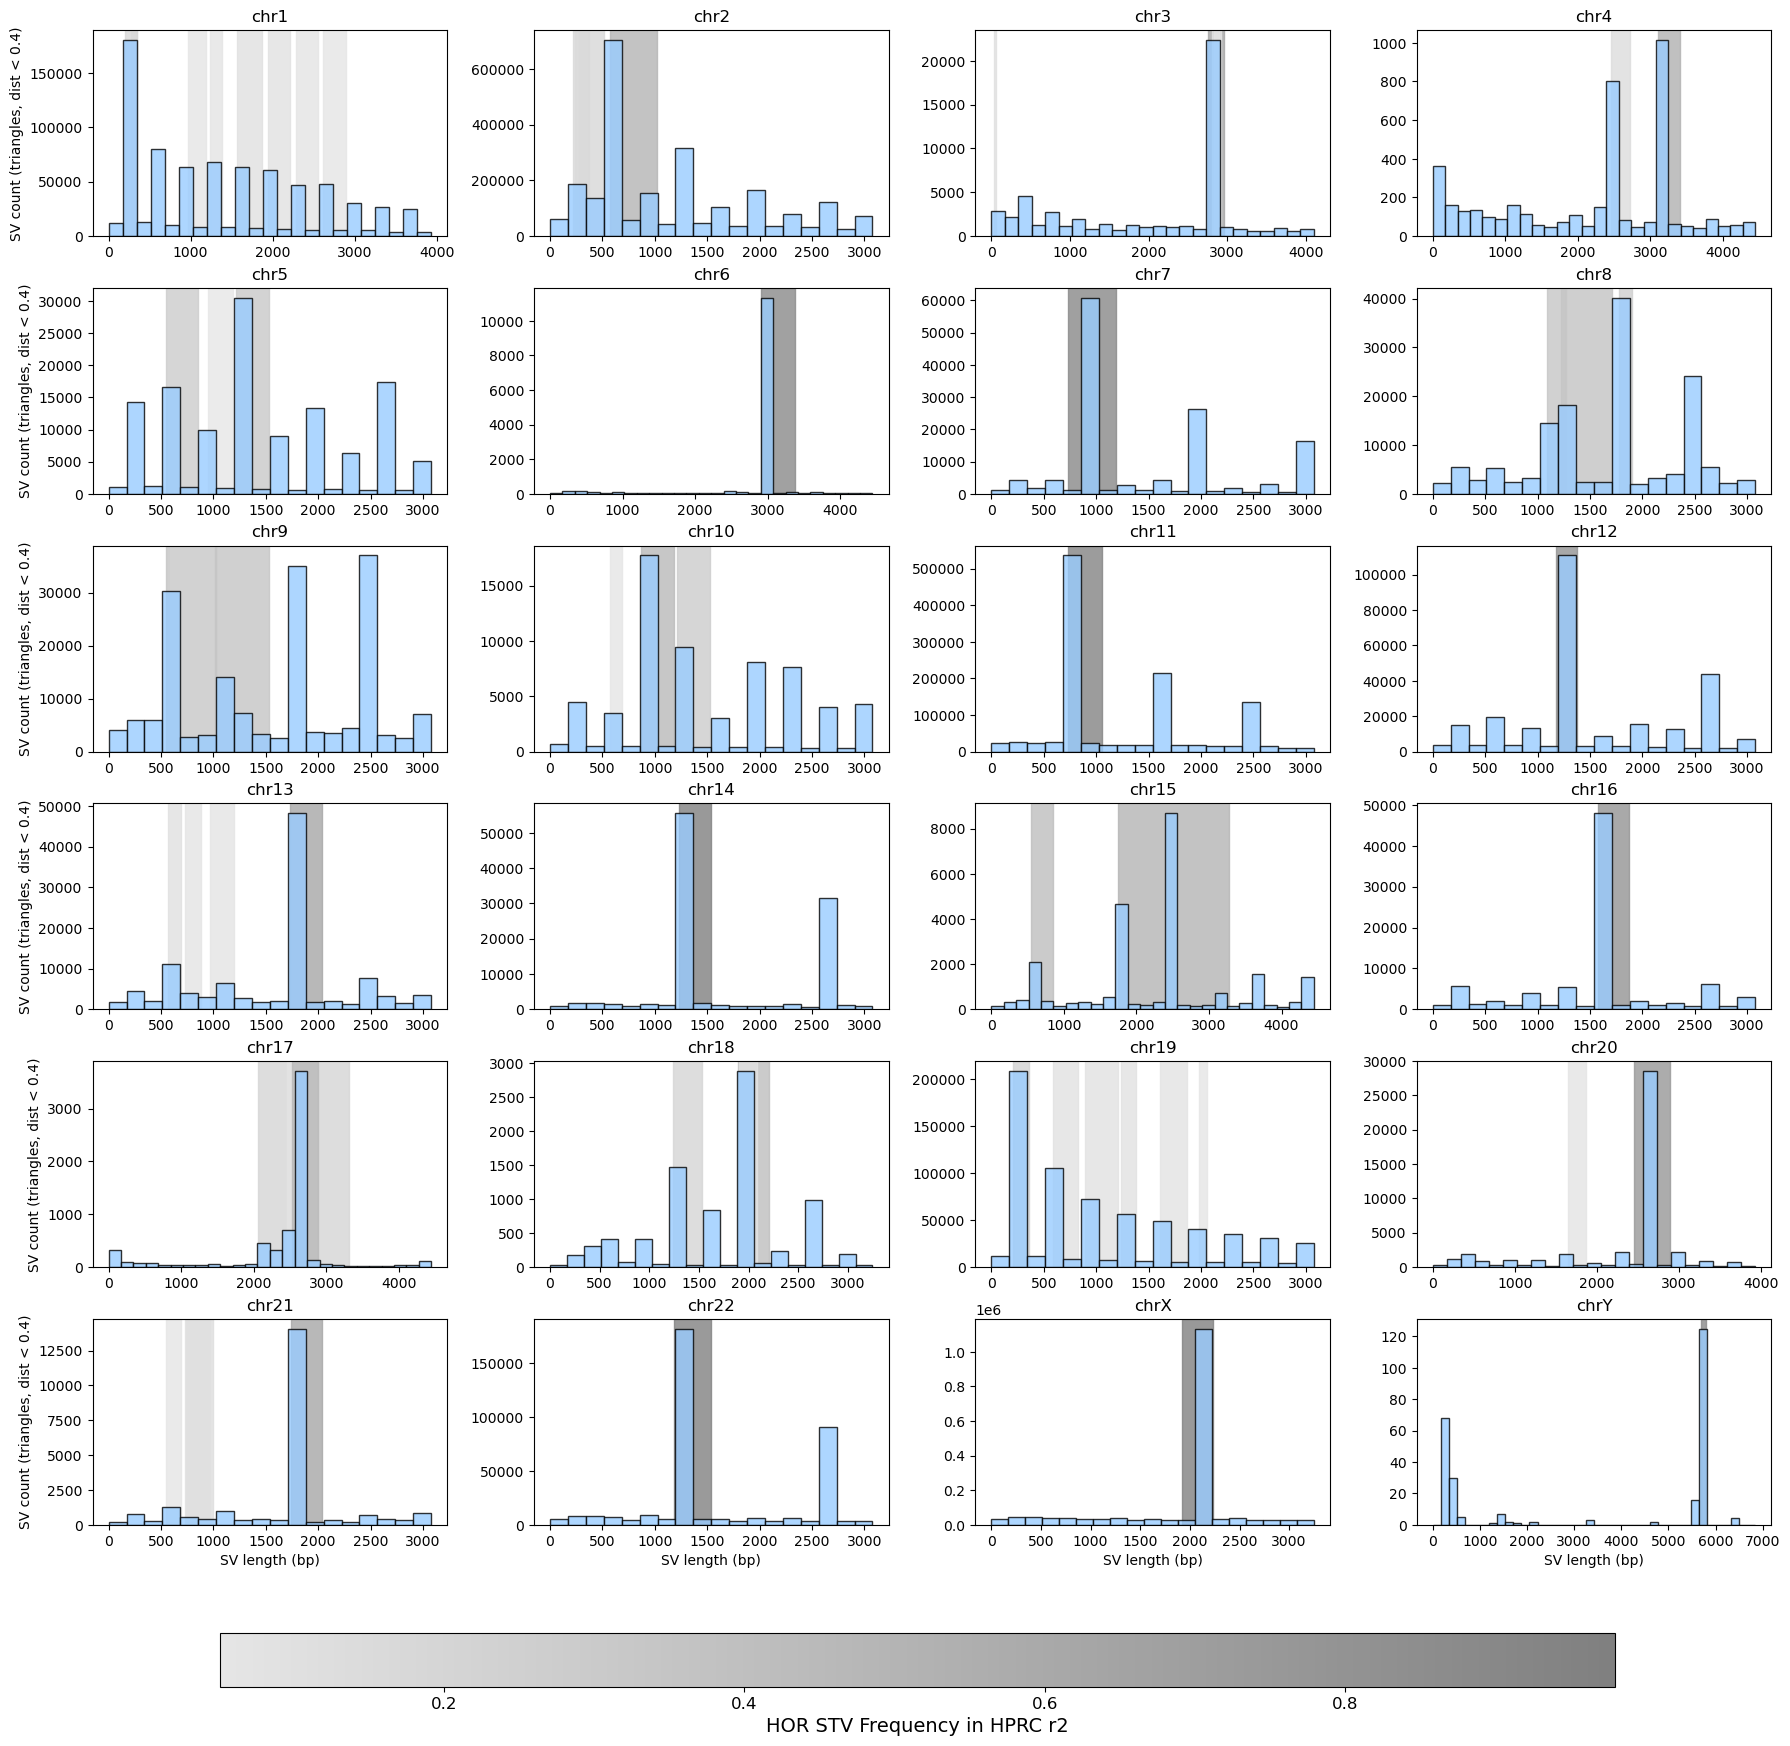

In [11]:
# Plot SV length distributions for all chromosomes, with expected HOR size overlayed
# Incorporated shading by frequency for HOR sizes 
# Incorporated fixed bins at 171 bp so the monomers pop

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import gridspec


# --------- LIGHTENED GREYS COLORMAP (key fix) ----------
def lighten_greys(low=0.65, high=0.90):
    """
    Create a lightened grayscale colormap where:
        0.0 maps to a light gray,
        1.0 maps to a slightly darker gray.
    The frequency range (Normalize) stays FULL.
    """
    return mcolors.LinearSegmentedColormap.from_list(
        "light_greys_fullrange",
        [cm.Greys(low), cm.Greys(high)]
    )


# ----------------------
# 3. Plot histograms on same grid
# ----------------------
n_chrom = len(chromosomes)
n_cols = 4
n_rows = int(np.ceil(n_chrom / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3),
                         sharex=False, sharey=False)
axes = axes.flatten()


# --------- NORMALIZATION: FULL RANGE OF TRUE FREQUENCIES ----------
freq_min = chm13_stvs["chrom_freq"].min()
freq_max = chm13_stvs["chrom_freq"].max()
norm = mcolors.Normalize(vmin=freq_min, vmax=freq_max)

# --------- NEW LIGHT GRAY COLORMAP ----------
# Light gray colormap from RGB tuples
cmap = mcolors.LinearSegmentedColormap.from_list(
    "light_greys_rev",
    [(0.9, 0.9, 0.9),  # light gray → low frequency
     (0.5, 0.5, 0.5)]     # darker gray → high frequency
)

for i, chrom in enumerate(chromosomes):
    ax = axes[i]

    lengths = df_sub[df_sub["chr"] == chrom]["length"]

    # Determine max x limit for histogram
    ranges = chm13_stvs[chm13_stvs["chr"] == chrom]
    if not ranges.empty:
        max_len = ranges["max_range"].max()
        x_max = max(max_len + 1000, 3000)
    else:
        x_max = 3000

    # Histogram bins of 171 bp
    x_bins = np.arange(0, x_max + 171, 171)
    ax.hist(lengths, bins=x_bins,
        color=(0.6, 0.8, 1.0),  # RGB tuple for light blue
        edgecolor='black',
        alpha=0.8)

    # Plot rectangles for each STV shaded by chrom_freq
    for _, row in ranges.iterrows():
        color = cmap(norm(row["chrom_freq"]))
        ax.axvspan(
            row["min_range"], row["max_range"],
            color=color, alpha=0.8, edgecolor=None, zorder=0
        )

    ax.set_title(chrom)

    # y-axis label only on left
    if i % n_cols == 0:
        ax.set_ylabel("SV count (triangles, dist < 0.4)")
    else:
        ax.set_ylabel("")

    # x-axis labels only on bottom row
    if i // n_cols == n_rows - 1:
        ax.set_xlabel("SV length (bp)")
    else:
        ax.set_xlabel("")


# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# Final layout
# Add colorbar in its own axes below the plots
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Create a separate axes for colorbar: [left, bottom, width, height]
cbar_ax = fig.add_axes([0.125, 0.06, 0.775, 0.03])  # tweak bottom/height as needed
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('HOR STV Frequency in HPRC r2',fontsize=14)
cbar.ax.tick_params(labelsize=12)


plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()


#### Plot STV sizes for triangles and trapezoids where dist < 0.2

In [12]:
df_sub = df_sv_sorted[
    (df_sv_sorted['shape'].isin(['triangle', 'trapezoid'])) &
    (df_sv_sorted['pairwise_dist'] < 0.2)
]

/data/tmp/ipykernel_1397777/845576139.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


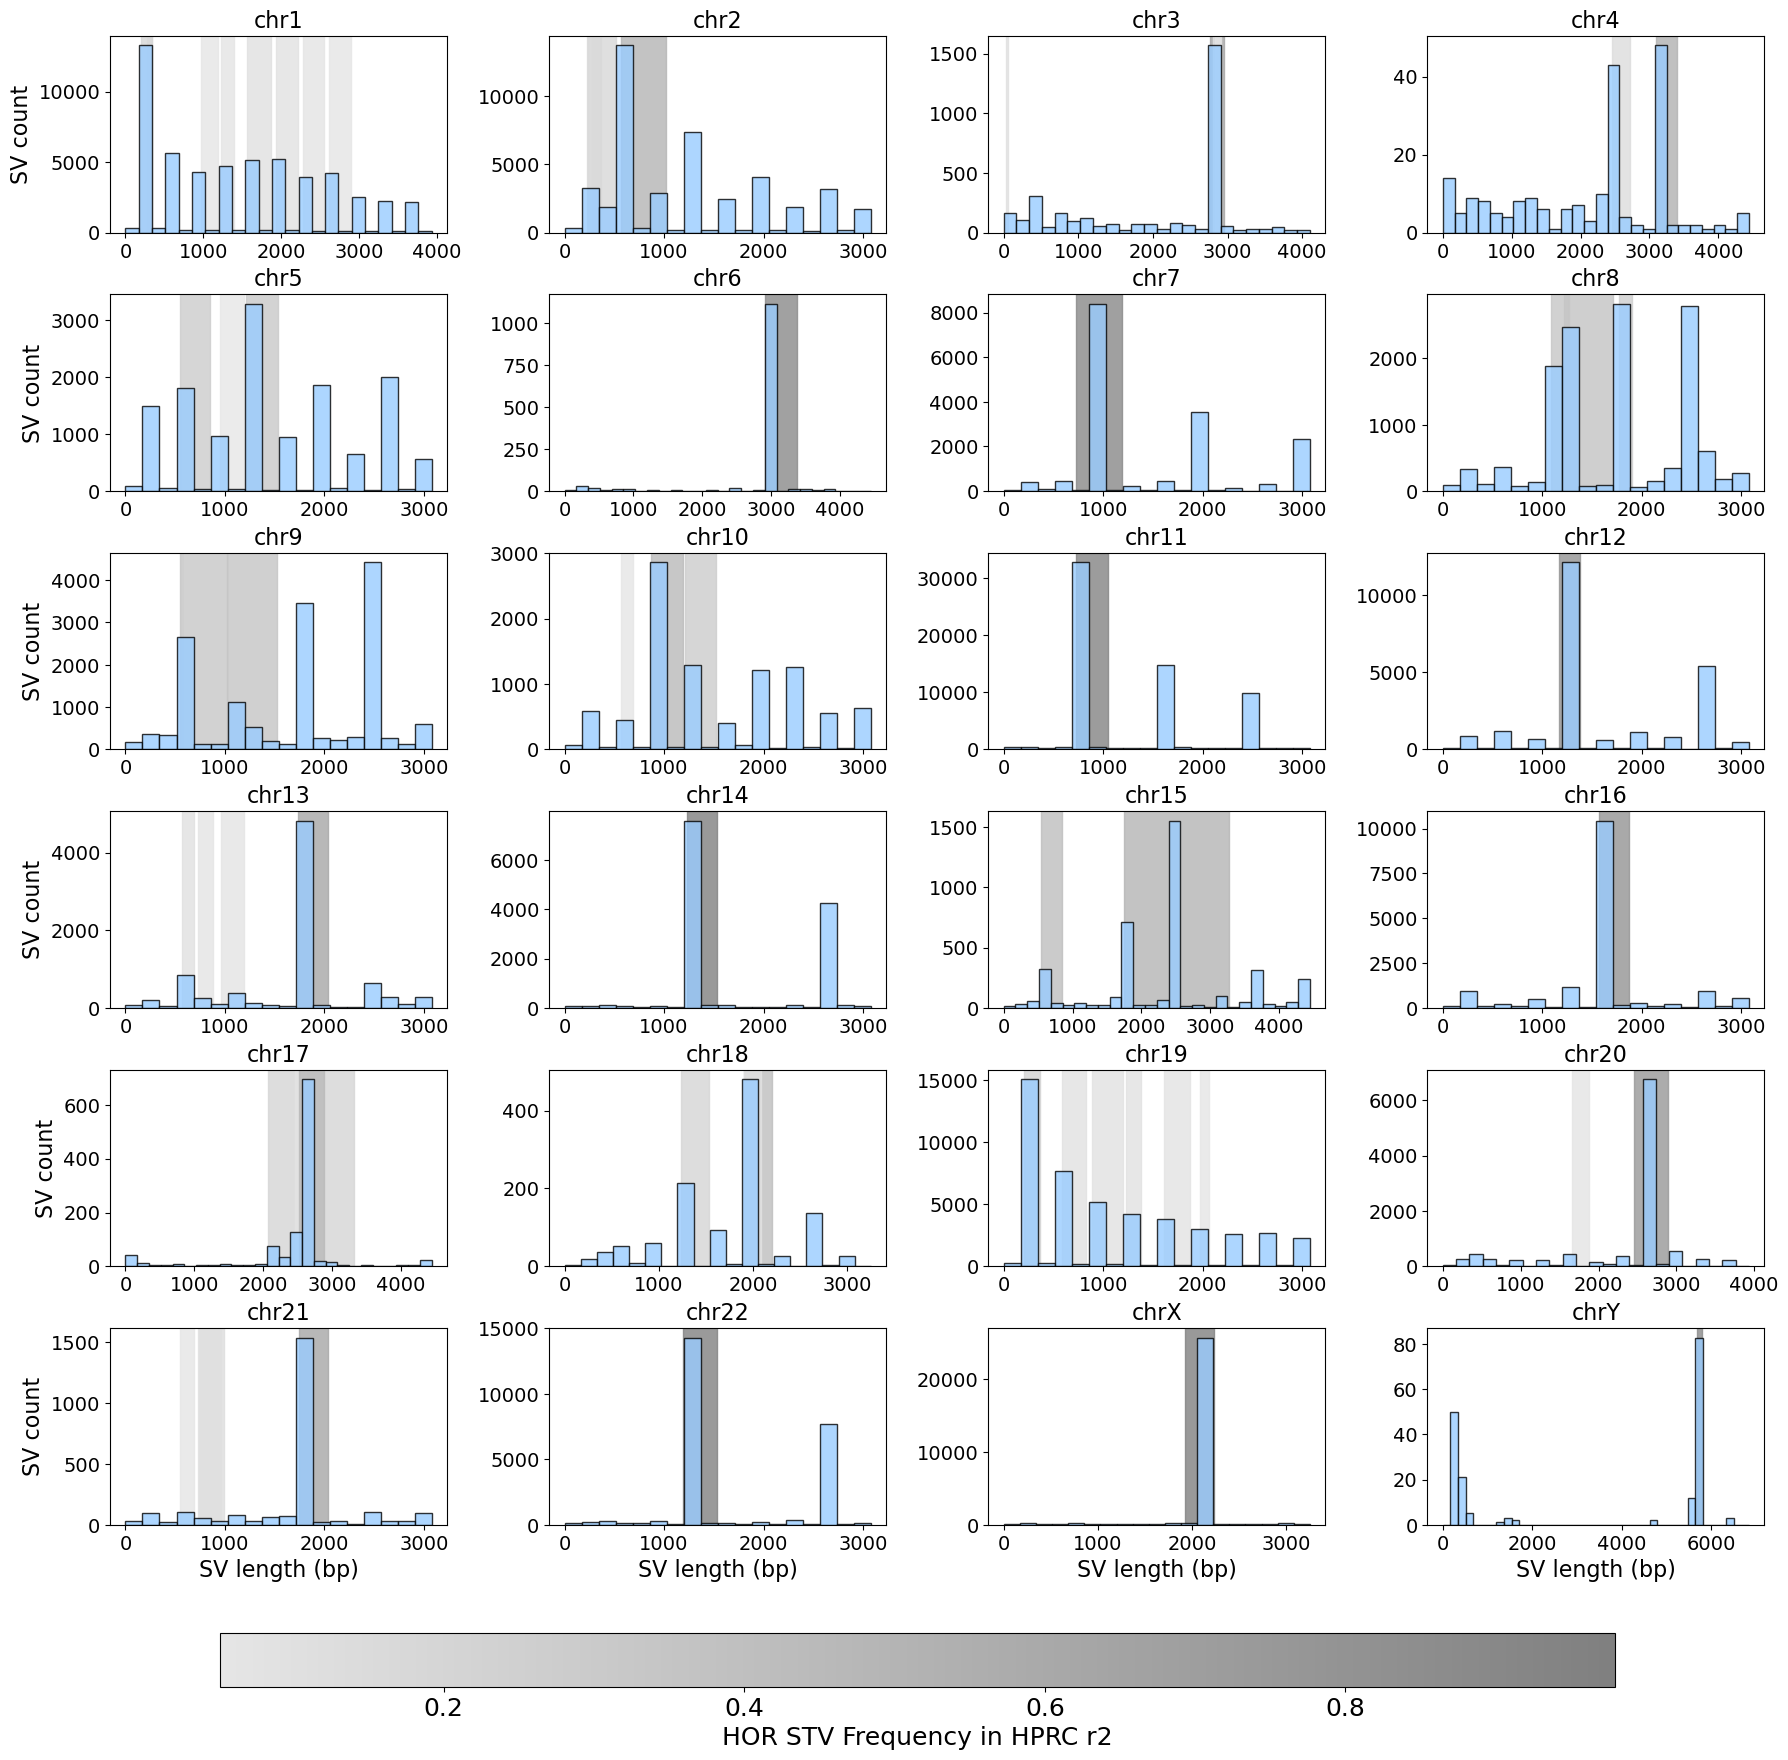

In [22]:
# Plot SV length distributions for all chromosomes, with expected HOR size overlayed
# Incorporated shading by frequency for HOR sizes 
# Incorporated fixed bins at 171 bp so the monomers pop

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import gridspec


# --------- LIGHTENED GREYS COLORMAP (key fix) ----------
def lighten_greys(low=0.65, high=0.90):
    """
    Create a lightened grayscale colormap where:
        0.0 maps to a light gray,
        1.0 maps to a slightly darker gray.
    The frequency range (Normalize) stays FULL.
    """
    return mcolors.LinearSegmentedColormap.from_list(
        "light_greys_fullrange",
        [cm.Greys(low), cm.Greys(high)]
    )


# ----------------------
# 3. Plot histograms on same grid
# ----------------------
n_chrom = len(chromosomes)
n_cols = 4
n_rows = int(np.ceil(n_chrom / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3),
                         sharex=False, sharey=False)
axes = axes.flatten()


# --------- NORMALIZATION: FULL RANGE OF TRUE FREQUENCIES ----------
freq_min = chm13_stvs["chrom_freq"].min()
freq_max = chm13_stvs["chrom_freq"].max()
norm = mcolors.Normalize(vmin=freq_min, vmax=freq_max)

# --------- NEW LIGHT GRAY COLORMAP ----------
# Light gray colormap from RGB tuples
cmap = mcolors.LinearSegmentedColormap.from_list(
    "light_greys_rev",
    [(0.9, 0.9, 0.9),  # light gray → low frequency
     (0.5, 0.5, 0.5)]     # darker gray → high frequency
)

for i, chrom in enumerate(chromosomes):
    ax = axes[i]

    lengths = df_sub[df_sub["chr"] == chrom]["length"]

    # Determine max x limit for histogram
    ranges = chm13_stvs[chm13_stvs["chr"] == chrom]
    if not ranges.empty:
        max_len = ranges["max_range"].max()
        x_max = max(max_len + 1000, 3000)
    else:
        x_max = 3000

    # Histogram bins of 171 bp
    x_bins = np.arange(0, x_max + 171, 171)
    ax.hist(lengths, bins=x_bins,
        color=(0.6, 0.8, 1.0),  # RGB tuple for light blue
        edgecolor='black',
        alpha=0.8)

    # Plot rectangles for each STV shaded by chrom_freq
    for _, row in ranges.iterrows():
        color = cmap(norm(row["chrom_freq"]))
        ax.axvspan(
            row["min_range"], row["max_range"],
            color=color, alpha=0.8, edgecolor=None, zorder=0
        )

    ax.set_title(chrom,fontsize=16)

    # y-axis label only on left
    if i % n_cols == 0:
        ax.set_ylabel("SV count",fontsize=16)
    else:
        ax.set_ylabel("")

    # x-axis labels only on bottom row
    if i // n_cols == n_rows - 1:
        ax.set_xlabel("SV length (bp)",fontsize=16)
    else:
        ax.set_xlabel("")

    ax.tick_params(axis='both', labelsize=14)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# Final layout
# Add colorbar in its own axes below the plots
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Create a separate axes for colorbar: [left, bottom, width, height]
cbar_ax = fig.add_axes([0.125, 0.06, 0.775, 0.03])  # tweak bottom/height as needed
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('HOR STV Frequency in HPRC r2',fontsize=18)
cbar.ax.tick_params(labelsize=18)


plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig('/private/groups/patenlab/mira/SV_size_dist_STVs.dist0.2.supplement.svg', format='svg', bbox_inches='tight')

plt.show()
